In [1]:
import pandas as pd

In [9]:
import matplotlib.pyplot as plt


In [3]:
# direction == 2
# 0) 读数据 & 取中间直行车道的车辆（你已有 df_list 的办法）
df_all = pd.read_csv("./0400pm-0415pm/trajectories-0400pm-0415pm.csv")

# 12th (Int_ID=3) + NB (Direction=2) + 中间直行车辆
df3 = df_all[(df_all.Int_ID==3) & (df_all.Direction==2)]

# df3 = df_all[(df_all.Int_ID==3) & (df_all.Direction==4)]
df_list = df3[(df3.Local_X<20)&(df3.Local_X>10)&(df3.Local_Y<1190)].Vehicle_ID.unique()
df3_mid = df3[df3.Vehicle_ID.isin(df_list)].copy()


# 上游 Int_ID=2，同一批车、同方向
df2_up = df_all[(df_all.Int_ID==2) & (df_all.Direction==2) & (df_all.Vehicle_ID.isin(df_list))].copy()

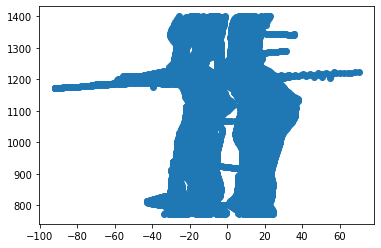

In [20]:
df_all = pd.read_csv("./0400pm-0415pm/trajectories-0400pm-0415pm.csv")
df_plot = df_all[(df_all.Local_Y<1400)& (df_all.Local_Y>773)]
plt.scatter(df_plot.Local_X,df_plot.Local_Y)

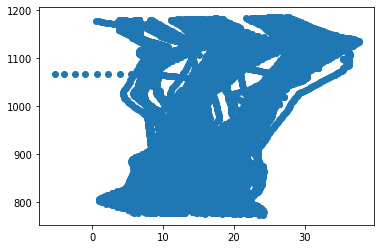

In [27]:
df_plot = df_all[(df_all.Section_ID==3) & (df_all.Direction==2)]
plt.scatter(df_plot.Local_X,df_plot.Local_Y)

In [30]:
df_plot.Global_Time.max()

1163983400

In [31]:
df_plot.Global_Time.min()

1163077500

In [21]:
df_all[df_all.Section_ID==3].Local_Y.max()

1185.639

In [22]:
df_all[df_all.Section_ID==3].Local_Y.min()

773.467

In [33]:
import os
import numpy as np
import pandas as pd


# =========================================================
# 0. 参数
# =========================================================
TRAJ_PATH = "./0400pm-0415pm/trajectories-0400pm-0415pm.csv"
SIGNAL_PATH = "./0400pm-0415pm/Peachtree_12th_NB_0400-0415.csv"
OUTPUT_PATH = "./cycle_stats_12th_NB_section3_definitionB.csv"

TARGET_INT_ID = 3
TARGET_SECTION_ID = 3

# NGSIM 编码: NB=2, TH=1
TARGET_DIRECTION = 2
TARGET_MOVEMENT = 1

# 如果你确定只要 lane 2，就写 [2]
# 如果你后面发现 lane 变化或 lane 2 太窄，可改成 None 或 [1,2]
TARGET_LANES = [2]

# 空间区域
UPSTREAM_Y = 985.0
STOPLINE_Y = 1185.0
REGION_LEN_FT = STOPLINE_Y - UPSTREAM_Y

# 速度阈值: 低速/停车判定
QUEUE_SPEED_THRESHOLD_FPS = 5.0

# 相邻排队车辆最大净间距阈值
MAX_NET_GAP_FT = 25.0

# 初始启动损失，计算饱和车头时距时忽略前几辆
STARTUP_LOST_VEHICLES = 3

# 帧间隔，NGSIM 通常 10Hz
DT = 0.1


# =========================================================
# 1. 读数据
# =========================================================
def read_signal_file(path):
    sig = pd.read_csv(path)
    sig.columns = [c.strip() for c in sig.columns]

    needed = ["BG_Thru", "BY_Thru", "BR_Thru"]
    miss = [c for c in needed if c not in sig.columns]
    if miss:
        raise ValueError(f"Signal file missing columns: {miss}")

    sig = sig.sort_values("BG_Thru").reset_index(drop=True)
    return sig


def read_trajectory_file(path):
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    return df


# =========================================================
# 2. 过滤 12th NB section 3 相关车辆
# =========================================================
def filter_target_vehicles(df):
    d = df.copy()

    # 基础方向筛选
    d = d[
        (d["Direction"] == TARGET_DIRECTION) &
        (d["Movement"] == TARGET_MOVEMENT)
    ].copy()

    if TARGET_LANES is not None:
        d = d[d["Lane_ID"].isin(TARGET_LANES)].copy()

    # 保留会出现在 section 3 / int 3 / region 附近的车辆
    keep_vids = []
    for vid, g in d.groupby("Vehicle_ID"):
        g = g.sort_values("Frame_ID")

        cond_section3 = (g["Section_ID"] == TARGET_SECTION_ID).any()
        cond_int3 = (g["Int_ID"] == TARGET_INT_ID).any()
        cond_region = ((g["Local_Y"] >= UPSTREAM_Y - 20) & (g["Local_Y"] <= STOPLINE_Y + 20)).any()

        if cond_section3 or cond_int3 or cond_region:
            keep_vids.append(vid)

    d = d[d["Vehicle_ID"].isin(keep_vids)].copy()
    d = d.sort_values(["Vehicle_ID", "Frame_ID"]).reset_index(drop=True)
    return d


# =========================================================
# 3. crossing 提取
#    这里只是为了 arrival / discharge / travel time
# =========================================================
def interpolate_crossing_frame(y0, y1, f0, f1, target_y):
    if y1 == y0:
        return float(f0)
    ratio = (target_y - y0) / (y1 - y0)
    return f0 + ratio * (f1 - f0)


def extract_vehicle_events(df):
    rows = []

    for vid, g in df.groupby("Vehicle_ID"):
        g = g.sort_values("Frame_ID").reset_index(drop=True)

        enter_985_frame = np.nan
        cross_1185_frame = np.nan

        for i in range(1, len(g)):
            prev = g.iloc[i - 1]
            curr = g.iloc[i]

            y0, y1 = prev["Local_Y"], curr["Local_Y"]
            f0, f1 = prev["Frame_ID"], curr["Frame_ID"]

            # NB: Local_Y 随前进增大
            if pd.isna(enter_985_frame):
                if (y0 < UPSTREAM_Y) and (y1 >= UPSTREAM_Y):
                    enter_985_frame = interpolate_crossing_frame(y0, y1, f0, f1, UPSTREAM_Y)

            if pd.isna(cross_1185_frame):
                if (y0 < STOPLINE_Y) and (y1 >= STOPLINE_Y):
                    cross_1185_frame = interpolate_crossing_frame(y0, y1, f0, f1, STOPLINE_Y)

        if pd.notna(enter_985_frame) and pd.notna(cross_1185_frame):
            travel_time = (cross_1185_frame - enter_985_frame) * DT
        else:
            travel_time = np.nan

        rows.append({
            "Vehicle_ID": vid,
            "enter_985_frame": enter_985_frame,
            "cross_1185_frame": cross_1185_frame,
            "travel_time_985_to_1185_s": travel_time
        })

    return pd.DataFrame(rows)


# =========================================================
# 4. 时刻插值快照
# =========================================================
def interpolate_snapshot(df, query_frame):
    snaps = []

    for vid, g in df.groupby("Vehicle_ID"):
        g = g.sort_values("Frame_ID").reset_index(drop=True)
        f = g["Frame_ID"].values

        if query_frame < f.min() or query_frame > f.max():
            continue

        j = np.searchsorted(f, query_frame)

        if j == 0:
            r0 = r1 = g.iloc[0]
            frac = 0.0
        elif j >= len(g):
            r0 = r1 = g.iloc[-1]
            frac = 0.0
        else:
            r0 = g.iloc[j - 1]
            r1 = g.iloc[j]
            if r1["Frame_ID"] == r0["Frame_ID"]:
                frac = 0.0
            else:
                frac = (query_frame - r0["Frame_ID"]) / (r1["Frame_ID"] - r0["Frame_ID"])

        row = {}
        for col in ["Vehicle_ID", "Lane_ID", "Section_ID", "Int_ID", "Direction", "Movement"]:
            row[col] = r0[col]

        row["Frame_ID"] = query_frame
        row["Local_X"] = r0["Local_X"] + frac * (r1["Local_X"] - r0["Local_X"])
        row["Local_Y"] = r0["Local_Y"] + frac * (r1["Local_Y"] - r0["Local_Y"])
        row["v_Vel"] = r0["v_Vel"] + frac * (r1["v_Vel"] - r0["v_Vel"])
        row["v_Length"] = r0["v_Length"]

        snaps.append(row)

    snap = pd.DataFrame(snaps)
    return snap


# =========================================================
# 5. Definition B: 物理长度式队列识别
#    逻辑:
#    - 只看 985~1185 区域内车辆
#    - 从最靠近 stopline 的低速车开始
#    - 向上游找连续低速且间距不大的车辆
#    - 队列长度 = stopline_y - 最后一辆排队车尾部位置
# =========================================================
def identify_queue_definition_B(
    snap,
    stopline_y=STOPLINE_Y,
    upstream_y=UPSTREAM_Y,
    speed_threshold_fps=QUEUE_SPEED_THRESHOLD_FPS,
    max_net_gap_ft=MAX_NET_GAP_FT,
):
    if snap.empty:
        return {
            "queue_vehicle_ids": [],
            "queue_vehicle_count": 0,
            "queue_length_ft": 0.0
        }

    # 只看研究区域内车辆
    cand = snap[
        (snap["Local_Y"] >= upstream_y) &
        (snap["Local_Y"] < stopline_y)
    ].copy()

    if TARGET_LANES is not None:
        cand = cand[cand["Lane_ID"].isin(TARGET_LANES)].copy()

    if cand.empty:
        return {
            "queue_vehicle_ids": [],
            "queue_vehicle_count": 0,
            "queue_length_ft": 0.0
        }

    # 对 NB，按 Local_Y 从大到小排序: 越靠前越接近 stopline
    cand = cand.sort_values("Local_Y", ascending=False).reset_index(drop=True)

    queue_rows = []

    for i in range(len(cand)):
        row = cand.iloc[i]
        front_y = row["Local_Y"]
        length = row["v_Length"]
        tail_y = front_y - length
        speed = row["v_Vel"]

        if i == 0:
            # 队首必须足够接近 stopline 且低速
            if (stopline_y - front_y <= 30.0) and (speed <= speed_threshold_fps):
                queue_rows.append({
                    "Vehicle_ID": row["Vehicle_ID"],
                    "front_y": front_y,
                    "tail_y": tail_y,
                    "speed": speed,
                    "v_Length": length
                })
            else:
                break
        else:
            prev = queue_rows[-1]
            prev_tail_y = prev["tail_y"]

            # 当前车的 front_y 应在前一辆尾部之后不远处
            net_gap = prev_tail_y - front_y

            if (speed <= speed_threshold_fps) and (net_gap <= max_net_gap_ft):
                queue_rows.append({
                    "Vehicle_ID": row["Vehicle_ID"],
                    "front_y": front_y,
                    "tail_y": tail_y,
                    "speed": speed,
                    "v_Length": length
                })
            else:
                break

    if len(queue_rows) == 0:
        return {
            "queue_vehicle_ids": [],
            "queue_vehicle_count": 0,
            "queue_length_ft": 0.0
        }

    rear_tail_y = min(r["tail_y"] for r in queue_rows)
    queue_length = max(0.0, stopline_y - rear_tail_y)

    # 不允许超过研究区域长度太多
    queue_length = min(queue_length, stopline_y - upstream_y)

    return {
        "queue_vehicle_ids": [r["Vehicle_ID"] for r in queue_rows],
        "queue_vehicle_count": len(queue_rows),
        "queue_length_ft": float(queue_length)
    }


# =========================================================
# 6. 周期统计
# =========================================================
def compute_cycle_stats(df, sig, veh_events):
    cycle_rows = []

    # 至少要有两个 BG 才能定义一个完整 cycle
    for c in range(len(sig) - 1):
        bg = float(sig.loc[c, "BG_Thru"])
        by = float(sig.loc[c, "BY_Thru"])
        br = float(sig.loc[c, "BR_Thru"])
        next_bg = float(sig.loc[c + 1, "BG_Thru"])

        cycle_length_s = (next_bg - bg) * DT
        green_s = (by - bg) * DT
        yellow_s = (br - by) * DT
        red_s = (next_bg - br) * DT

        # -------------------------
        # A. 初始队列: BG 时刻
        # -------------------------
        snap_bg = interpolate_snapshot(df, bg)
        init_q = identify_queue_definition_B(snap_bg)

        # -------------------------
        # B. 残余队列: BR 时刻
        # -------------------------
        snap_br = interpolate_snapshot(df, br)
        resid_q = identify_queue_definition_B(snap_br)

        # -------------------------
        # C. arrival: 本周期进入 985 的车辆数
        # -------------------------
        arr_df = veh_events[
            (veh_events["enter_985_frame"] >= bg) &
            (veh_events["enter_985_frame"] < next_bg)
        ].copy()
        arrival_count_985 = len(arr_df)

        # -------------------------
        # D. discharge: [BG, BR) 内越过 1185 的车辆数
        # -------------------------
        dep_df = veh_events[
            (veh_events["cross_1185_frame"] >= bg) &
            (veh_events["cross_1185_frame"] < br)
        ].copy().sort_values("cross_1185_frame")
        discharge_count_1185 = len(dep_df)

        # -------------------------
        # E. travel time: 985 -> 1185
        # -------------------------
        trav_df = arr_df.dropna(subset=["travel_time_985_to_1185_s"]).copy()
        mean_travel_time_s = trav_df["travel_time_985_to_1185_s"].mean() if len(trav_df) > 0 else np.nan
        median_travel_time_s = trav_df["travel_time_985_to_1185_s"].median() if len(trav_df) > 0 else np.nan

        # -------------------------
        # F. queue clearance time
        #    初始队列车辆在本次绿黄期间完成过线的最后时刻
        # -------------------------
        init_q_vids = init_q["queue_vehicle_ids"]
        init_q_dep = veh_events[
            veh_events["Vehicle_ID"].isin(init_q_vids)
        ].dropna(subset=["cross_1185_frame"]).copy()

        init_q_dep = init_q_dep[
            (init_q_dep["cross_1185_frame"] >= bg) &
            (init_q_dep["cross_1185_frame"] < br)
        ].sort_values("cross_1185_frame")

        if len(init_q_vids) > 0 and len(init_q_dep) > 0:
            last_clear_frame = init_q_dep["cross_1185_frame"].max()
            queue_clearance_time_s = (last_clear_frame - bg) * DT
        else:
            queue_clearance_time_s = np.nan

        # -------------------------
        # G. sat headway
        #    仅对初始排队车辆的放行序列
        # -------------------------
        sat_headway_s = np.nan
        if len(init_q_dep) >= STARTUP_LOST_VEHICLES + 2:
            dep_times = init_q_dep["cross_1185_frame"].values * DT
            headways = np.diff(dep_times)

            # 忽略前 STARTUP_LOST_VEHICLES-1 个车头时距
            drop_n = max(STARTUP_LOST_VEHICLES - 1, 0)
            stable_headways = headways[drop_n:]

            # 做一个基本合理性过滤
            stable_headways = stable_headways[
                (stable_headways >= 0.5) & (stable_headways <= 5.0)
            ]

            if len(stable_headways) > 0:
                sat_headway_s = float(np.mean(stable_headways))

        cycle_rows.append({
            "cycle_id": c + 1,

            "BG_Thru": bg,
            "BY_Thru": by,
            "BR_Thru": br,
            "next_BG_Thru": next_bg,

            "cycle_length_s": cycle_length_s,
            "green_s": green_s,
            "yellow_s": yellow_s,
            "red_s": red_s,

            "region_start_y": UPSTREAM_Y,
            "stopline_y": STOPLINE_Y,
            "region_length_ft": REGION_LEN_FT,

            "initial_queue_length_ft": init_q["queue_length_ft"],
            "initial_queue_vehicle_count": init_q["queue_vehicle_count"],
            "initial_queue_vehicle_ids": init_q["queue_vehicle_ids"],

            "residual_queue_length_ft": resid_q["queue_length_ft"],
            "residual_queue_vehicle_count": resid_q["queue_vehicle_count"],
            "residual_queue_vehicle_ids": resid_q["queue_vehicle_ids"],

            "arrival_count_985": arrival_count_985,
            "arrival_rate_vps": arrival_count_985 / cycle_length_s if cycle_length_s > 0 else np.nan,

            "discharge_count_1185": discharge_count_1185,
            "discharge_rate_green_yellow_vps": discharge_count_1185 / max((br - bg) * DT, 1e-6),

            "mean_travel_time_985_to_1185_s": mean_travel_time_s,
            "median_travel_time_985_to_1185_s": median_travel_time_s,

            "queue_clearance_time_s": queue_clearance_time_s,
            "sat_headway_s": sat_headway_s,
        })

    return pd.DataFrame(cycle_rows)


# =========================================================
# 7. 主程序
# =========================================================
def main():
    df_all = read_trajectory_file(TRAJ_PATH)
    sig = read_signal_file(SIGNAL_PATH)

    # 只保留目标对象
    df = filter_target_vehicles(df_all)

    print("Filtered rows:", len(df))
    print("Filtered vehicles:", df["Vehicle_ID"].nunique())

    # 车辆级事件
    veh_events = extract_vehicle_events(df)

    # 周期统计
    cycle_stats = compute_cycle_stats(df, sig, veh_events)

    cycle_stats.to_csv(OUTPUT_PATH, index=False)

    print("\nSaved to:", OUTPUT_PATH)
    print("\nFirst 10 cycles:")
    print(cycle_stats.head(10))

    print("\nSummary:")
    print(cycle_stats[[
        "initial_queue_length_ft",
        "residual_queue_length_ft",
        "arrival_count_985",
        "discharge_count_1185",
        "mean_travel_time_985_to_1185_s",
        "sat_headway_s"
    ]].describe())


if __name__ == "__main__":
    main()

Filtered rows: 46835
Filtered vehicles: 66

Saved to: ./cycle_stats_12th_NB_section3_definitionB.csv

First 10 cycles:
   cycle_id  BG_Thru  BY_Thru  BR_Thru  next_BG_Thru  cycle_length_s  green_s  \
0         1    948.0   1557.0   1589.0        1946.0            99.8     60.9   
1         2   1946.0   2554.0   2586.0        2943.0            99.7     60.8   
2         3   2943.0   3552.0   3584.0        3940.0            99.7     60.9   
3         4   3940.0   4549.0   4581.0        4939.0            99.9     60.9   
4         5   4939.0   5547.0   5579.0        5935.0            99.6     60.8   
5         6   5935.0   6544.0   6576.0        6932.0            99.7     60.9   
6         7   6932.0   7541.0   7573.0        7930.0            99.8     60.9   
7         8   7930.0   8539.0   8571.0        8926.0            99.6     60.9   
8         9   8926.0   9535.0   9567.0        9925.0            99.9     60.9   
9        10   9925.0  10533.0  10565.0       10921.0            99.6   